In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_adoptions.csv")

print(df.shape)
df.head()

(168227, 97)


,adopted,is_fixed,has_name,age_in_days,outcome_year,outcome_month,outcome_weekday,is_multicolor,is_mix,animal_type_Bird,...,primary_breed_German Shepherd,primary_breed_Great Pyrenees,primary_breed_Labrador Retriever,primary_breed_Miniature Poodle,primary_breed_Miniature Schnauzer,primary_breed_Other,primary_breed_Pit Bull,primary_breed_Siamese,primary_breed_Siberian Husky,primary_breed_Yorkshire Terrier
0,0,0,0,365.0,2013,12,0,1,1,False,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,365.0,2014,4,0,0,1,False,...,False,False,False,False,False,True,False,False,False,False
2,0,0,0,14.0,2014,6,1,1,0,True,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,14.0,2014,6,1,1,0,True,...,False,False,False,False,False,True,False,False,False,False
4,0,0,0,14.0,2014,6,1,1,0,True,...,False,False,False,False,False,True,False,False,False,False


In [13]:
# split features (X) from target var (y)
# X: data the model will learn from (animal_type_Dog, is_fixed, has_name, age_in_days, etc)
# y: what we want the model to predict (adopted binary)

X = df.drop(columns=['adopted'])
y = df['adopted']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Adoption rate: {y.mean().round(3) * 100}%")

Features shape: (168227, 96)
Target shape: (168227,)
Adoption rate: 51.0%


In [14]:
# split data in training (80%, what the model learns from) and testing (20%, withheld data used to eval model accuracy on unseen data) sets
# random_state=42 sets a seed so the split is reproducible, same split every time it runs

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (134581, 96)
Testing set: (33646, 96)


In [15]:
# initialize and train logistic regression model

# LogisticRegression: simple but powerful model for binary classification, great starting point
# max_iter=1000: gives model enough iterations to converge on a solution
# random_state=42: makes results reproducible
# .fit(): where actual learning happens, model finds patterns in X_train that predict y_train

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete")

Model training complete


/Users/helloklow/pet-adoption-predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# model did train, but hit iteration limit before fully converging 
# two fixes: increase max_iter and scale data

from sklearn.preprocessing import StandardScaler

# scale features (brings all cols to same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# retrain using higher max_iter
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [17]:
# evaluate model

# predict on test set
y_pred = model.predict(X_test_scaled)

# compare classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.78     16557
           1       0.76      0.88      0.82     17089

    accuracy                           0.80     33646
   macro avg       0.81      0.80      0.80     33646
weighted avg       0.80      0.80      0.80     33646



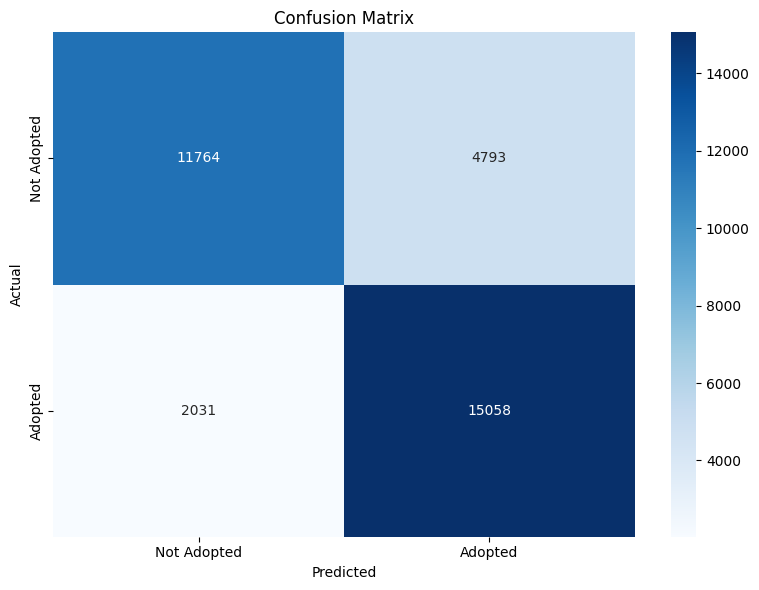

In [18]:
# visualize confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Adopted', 'Adopted'],
            yticklabels=['Not Adopted', 'Adopted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [24]:
# 15000 true positives
# 11800 true negatives
# 4800 false positives: predicted "adopted", but not adopted; over-optimisn, flagged pet as likely to be adopted when it won't be
# 2000 false negatives: predicted "not adopted", but likely to be; pets were incorrectly written off

In [20]:
# assess which features model relies on most to make predictions

# get feature importance from model coefficients
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# sort by absolute value to see strongest predictors regardless of direction
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

# show top 20
print(feature_importance.head(20))

                              feature  coefficient  abs_coefficient
0                            is_fixed     1.841641         1.841641
2                         age_in_days    -0.695801         0.695801
3                        outcome_year     0.569989         0.569989
15                        sex_Unknown    -0.353143         0.353143
12                  animal_type_Other     0.304829         0.304829
8                    animal_type_Bird     0.232274         0.232274
5                     outcome_weekday     0.231160         0.231160
1                            has_name     0.227533         0.227533
10                    animal_type_Dog    -0.150475         0.150475
13                         sex_Female     0.136622         0.136622
4                       outcome_month     0.117554         0.117554
92             primary_breed_Pit Bull    -0.094809         0.094809
47                 primary_color_Gray    -0.052676         0.052676
81  primary_breed_Chihuahua Shorthair     0.0494

In [21]:
# top predictors:
# is_fixed: fixed pets have strong positive, confirms eda
# primary_breed_Bat: strong negative, filter out wildlife
# age_in_days: younger pets have stronger positive, confism eda
# primary_breed_Raccoon: strong negative, filter out wildlife
# outcome_year: adoption rates trending up over time
# sex_Unknown: stronger negative
# has_name: stronger positive, confirms eda
# outcome_weekday: weekends spike, day of week has influence

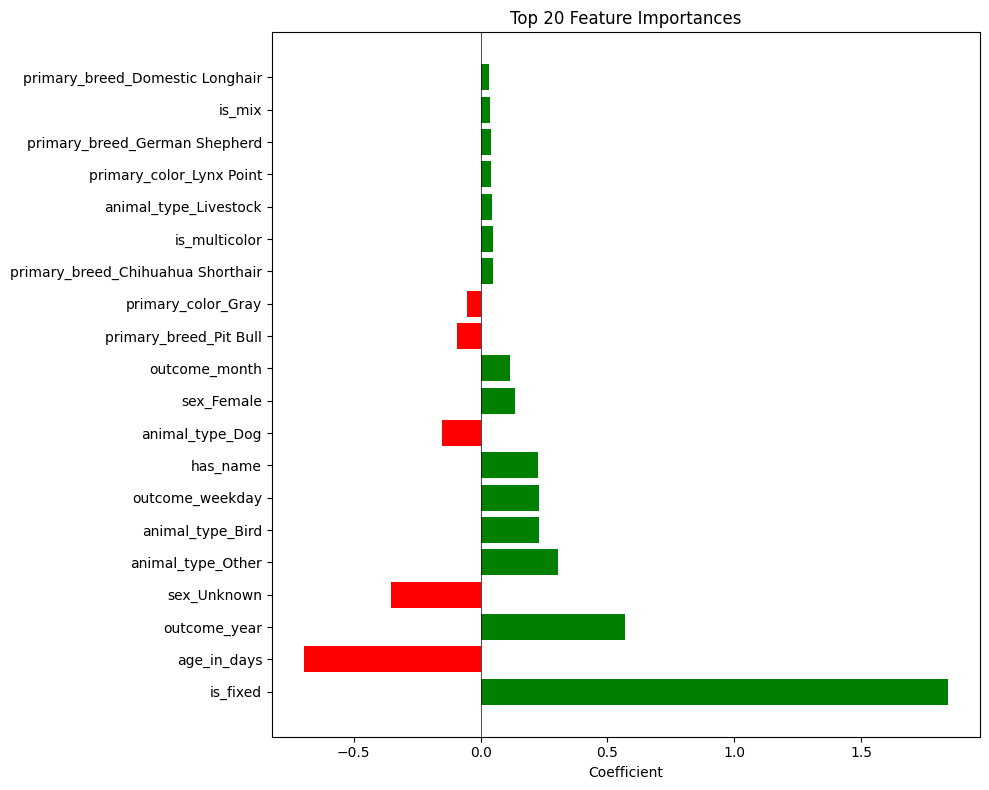

In [22]:
# visualize feature importance

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.title('Top 20 Feature Importances')
plt.xlabel('Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [26]:
# removed wildlife from dataset (in notebook 03) and re-trained model

# check if accuracy improved
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.78     16557
           1       0.76      0.88      0.82     17089

    accuracy                           0.80     33646
   macro avg       0.81      0.80      0.80     33646
weighted avg       0.80      0.80      0.80     33646



In [27]:
# accuracy stayed the same, wildlife didn't influence predictions
# "not adopted" precision/recall dropped slightly, wildlife were easy "not adopted" predictions
# dataset is cleaner and better represents actual shelter pets

In [31]:
# random forest model

from sklearn.ensemble import RandomForestClassifier

# initialize and train model
# n_estimators = number of trees in the forest (builds 100 trees and combines predictions)
# each tree learns from random subset of data
# final prediction is majority vote across all trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest training complete")

Random Forest training complete


In [32]:
# evaluate random forest

#make predictions
rf_pred = rf_model.predict(X_test)

# print classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81     16557
           1       0.80      0.85      0.82     17089

    accuracy                           0.82     33646
   macro avg       0.82      0.82      0.82     33646
weighted avg       0.82      0.82      0.82     33646



In [33]:
# random forest is 2% more accurate overall
# not adopted recall: significantly improved, 71% > 79%
# adopted precison: improved, 76% > 80%
# adopted recall: declined, 88% > 85%
# overall random forest is more balanced, captures complex, non-linear relationships bt features better

In [34]:
# check feature importance for random forest

# get feature importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values('importance', ascending=False)
print(rf_importance.head(20))

                              feature  importance
0                            is_fixed    0.260305
2                         age_in_days    0.207789
3                        outcome_year    0.107215
4                       outcome_month    0.103696
5                     outcome_weekday    0.079901
1                            has_name    0.032804
6                       is_multicolor    0.016331
7                              is_mix    0.014850
15                        sex_Unknown    0.012826
18                primary_color_Black    0.010309
72                primary_color_White    0.008051
91                primary_breed_Other    0.007330
10                    animal_type_Dog    0.006964
14                           sex_Male    0.006829
31                primary_color_Brown    0.006355
13                         sex_Female    0.006239
67                  primary_color_Tan    0.006053
81  primary_breed_Chihuahua Shorthair    0.004818
23                 primary_color_Blue    0.004791


In [35]:
# logistic regression vs random forest feature importance
# is_fixed most important in both
# age_in_days next most important in both
# outcome_year third most important in both
# has_name important in both
# logistic regression: sex_unknown more influential
# random forest: outcome_month and outcome_weekday more influential (timing more important that logreg can capture)
    # primary_color_Black in top 20, confirms "black pet syndrome" from eda

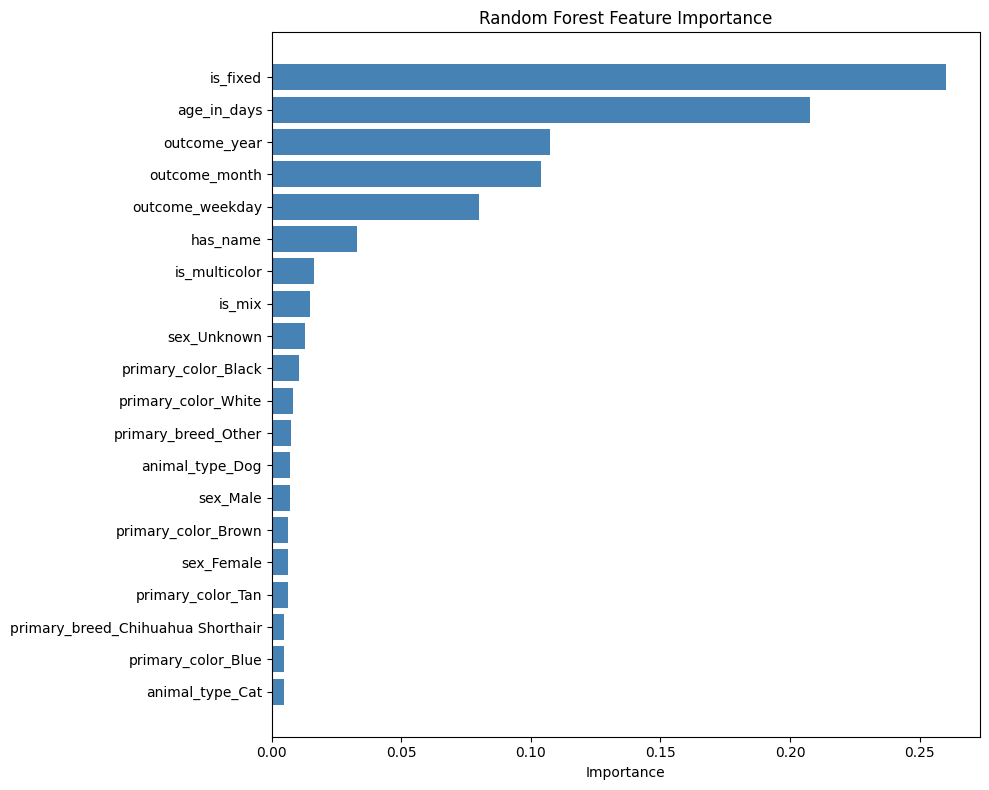

In [36]:
# visualize random forest feature importance

plt.figure(figsize=(10, 8))
plt.barh(rf_importance['feature'].head(20), rf_importance['importance'].head(20), color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
# logreg / random forest comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Not Adopted Precision', 'Not Adopted Recall', 
               'Adopted Precision', 'Adopted Recall'],
    'Logistic Regression': [
        f"{accuracy_score(y_test, y_pred):.2%}",
        f"{precision_score(y_test, y_pred, pos_label=0):.2%}",
        f"{recall_score(y_test, y_pred, pos_label=0):.2%}",
        f"{precision_score(y_test, y_pred, pos_label=1):.2%}",
        f"{recall_score(y_test, y_pred, pos_label=1):.2%}"
    ],
    'Random Forest': [
        f"{accuracy_score(y_test, rf_pred):.2%}",
        f"{precision_score(y_test, rf_pred, pos_label=0):.2%}",
        f"{recall_score(y_test, rf_pred, pos_label=0):.2%}",
        f"{precision_score(y_test, rf_pred, pos_label=1):.2%}",
        f"{recall_score(y_test, rf_pred, pos_label=1):.2%}"
    ]
})

print(comparison.to_string(index=False))

               Metric Logistic Regression Random Forest
             Accuracy              79.72%        81.59%
Not Adopted Precision              85.28%        83.10%
   Not Adopted Recall              71.05%        78.57%
    Adopted Precision              75.86%        80.28%
       Adopted Recall              88.12%        84.52%


In [38]:
# random forest: hyperparameter tuning

from sklearn.model_selection import GridSearchCV

# define parameter grid to search: combo of params to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# initialize grid search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3, # tests each combo on 3 different splits of training data
    scoring='accuracy', # optimizes for accuracy
    verbose=1, # prints progress as it runs
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2%}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/Users/helloklow/pet-adoption-predictor/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 82.07%


In [39]:
# train final model with best parameters
rf_tuned = RandomForestClassifier(
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81     16557
           1       0.79      0.88      0.83     17089

    accuracy                           0.82     33646
   macro avg       0.83      0.82      0.82     33646
weighted avg       0.83      0.82      0.82     33646



In [41]:
# full comparison of attempted models

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Not Adopted Precision', 'Not Adopted Recall', 
               'Adopted Precision', 'Adopted Recall'],
    'Logistic Regression': [
        f"{accuracy_score(y_test, y_pred):.2%}",
        f"{precision_score(y_test, y_pred, pos_label=0):.2%}",
        f"{recall_score(y_test, y_pred, pos_label=0):.2%}",
        f"{precision_score(y_test, y_pred, pos_label=1):.2%}",
        f"{recall_score(y_test, y_pred, pos_label=1):.2%}"
    ],
    'Random Forest': [
        f"{accuracy_score(y_test, rf_pred):.2%}",
        f"{precision_score(y_test, rf_pred, pos_label=0):.2%}",
        f"{recall_score(y_test, rf_pred, pos_label=0):.2%}",
        f"{precision_score(y_test, rf_pred, pos_label=1):.2%}",
        f"{recall_score(y_test, rf_pred, pos_label=1):.2%}"
    ],
    'Random Forest Tuned': [
        f"{accuracy_score(y_test, rf_tuned_pred):.2%}",
        f"{precision_score(y_test, rf_tuned_pred, pos_label=0):.2%}",
        f"{recall_score(y_test, rf_tuned_pred, pos_label=0):.2%}",
        f"{precision_score(y_test, rf_tuned_pred, pos_label=1):.2%}",
        f"{recall_score(y_test, rf_tuned_pred, pos_label=1):.2%}"
    ]
})

print(comparison.to_string(index=False))

               Metric Logistic Regression Random Forest Random Forest Tuned
             Accuracy              79.72%        81.59%              82.21%
Not Adopted Precision              85.28%        83.10%              86.44%
   Not Adopted Recall              71.05%        78.57%              75.73%
    Adopted Precision              75.86%        80.28%              79.00%
       Adopted Recall              88.12%        84.52%              88.49%


In [42]:
# random forest tuned: best accuracy overall, 82%
    # best not adopted precision, 86%
    # best adopted recall, 88%
    # most accurate at identifying adoptable pets
# tradeoff is not adopted recall and adopted precision, slightly lower than untuned random forest

In [44]:
# save model to be reused without retraining

import joblib # std lib for saving sklearn models
import os

# create models dir to store saved models separate from data
os.makedirs("../models", exist_ok=True)

# save tuned random forest model
joblib.dump(rf_tuned, "../models/rf_tuned.pkl") # .pkl format is serialized Python obj saved to disk

# save scaler
# prediction fn will need this to scale new inputs before predicting
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved")

Model and scaler saved
